# Chapter 4: Implementing a GPT model from scratch To Generate Text

This Chapter Covers
- Coding a GPT-like large language model (LLM) that can be trained to generate human-like text
- Normalizing layer activations to stabilize neural network training
- Adding shortcut connections in deep neural networks to train models more effectively
- Implementing transformer blocks to create GPT models of various sizes
- Computing the number of parameters and storage requirements of GPT models


## 4.1 Coding an LLM architecture

Configuration details for the 124 million parameter GPT-2 model include:

- vocab_size: The vocabulary size of 50,257 words.
- context_length: The model's maximum input token count.
- emb_dim: The dimension of embeddings of input tokens.
- n_heads: The number of attention heads in the multi-head attention.
- n_layers: The number of transformer blocks.
- drop_rate: The intensity of the dropout's mechanism.
- qkv_bias: Flag to include bias vector for Query, Key, Value layers or not.

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

Now, we code a class with dummy classes; just to illustrate the overall structure of the LLM.

In [2]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # Use a placeholder for TransformerBlock
        self.trf_blocks = nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        # Use a placeholder for LayerNorm
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

Generating output for the following input:

In [3]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

test_1 = "Every effort moves you"
test_2 = "Every day holds a"

batch = [torch.tensor(tokenizer.encode(test_1)), torch.tensor(tokenizer.encode(test_2))]
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [4]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print(f"Logits(ModelOutput).Shape:\n {logits.shape}\n")
print(f"Logits(ModelOutput):\n {logits}")

Logits(ModelOutput).Shape:
 torch.Size([2, 4, 50257])

Logits(ModelOutput):
 tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.2 Normalizing activations with layer normalization

In this section, we will implement layer normalization to improve the stability and efficiency of neural network training.

The main idea behind layer normalization is to adjust the activations (outputs) of a neural network layer to have a mean of 0 and a variance of 1, also known as unit variance.

Let's implement this process in a PyTorch module that we can use in the GPT model later:

In [5]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.epsilon = 1e-5 # To avoid division by zero errors, if variance is zero
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.epsilon)
        return self.scale * norm_x + self.shift

# The initial scale (multiplying by 1) and shift (adding 0) values don't have any effect.
# However, scale and shift are trainable parameters that the LLM automatically adjusts during training, 
# if it is determined that doing so would improve the model's performance on its training task

In [6]:
batch_example = torch.randn(3,5)
norm = LayerNorm(5)
out = norm(batch_example)

print(f"Out:\n {out}\n")
print("Out.Mean:\n",out.mean(dim=-1, keepdim=True),"\n")
print("Out.Variance:\n",out.var(dim=-1, keepdim=True, unbiased = False))

Out:
 tensor([[ 0.0455,  0.9326, -1.0036, -1.2364,  1.2619],
        [ 0.8868,  0.9411, -1.8051, -0.1976,  0.1748],
        [ 1.4930, -1.0058,  0.0240, -1.1578,  0.6466]], grad_fn=<AddBackward0>)

Out.Mean:
 tensor([[ 0.0000e+00],
        [-2.3842e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>) 

Out.Variance:
 tensor([[1.0000],
        [1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## 4.3 Implementing a Feed-Forward Network with GELU Activations

In this section, we implement a small neural network submodule that is used as part of the transformer block in LLMs.

In LLMs, various other types of activation functions are used beyond the traditional ReLU. Two notable examples are **GELU** (Gaussian Error Linear Unit) and **SwiGLU** (Swish-Gated Linear Unit).

The exact version of GELU is defined as:

$$
\text{GELU}(x) = x \cdot \Phi(x)
$$

where $\Phi(x)$ is the cumulative distribution function (CDF) of the standard Gaussian distribution.

In practice, it is common to implement a computationally cheaper approximation:

$$
\text{GELU}(x)
\approx
0.5 \cdot x \cdot
\left(
1 +
\tanh
\left(
\sqrt{\frac{2}{\pi}}
\cdot
\left(
x + 0.044715 \cdot x^3
\right)
\right)
\right)
$$

In [7]:

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

Let's plot these functions side by side:

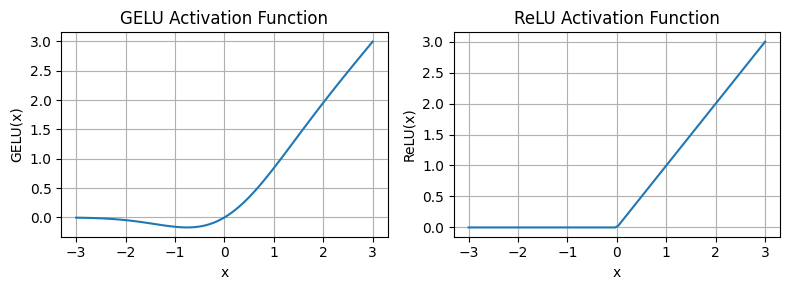

In [8]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

# Some sample data
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} Activation Function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

Next, let's use the GELU function to implement the small neural network module, FeedForward, that we will be using in the LLM's transformer block later:

In [9]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),GELU(),nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),)

    def forward(self, x):
        return self.layers(x)

## 4.4 Adding shortcut connections

Shortcut connections were proposed for deep networks in computer vision (specifically, in residual networks) to mitigate the challenge of vanishing gradients.

A shortcut connection creates an alternative, shorter path for the gradient to flow through the network by skipping one or more layers, which is achieved by adding the output of one layer to the output of a later layer.

In [10]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x


def print_gradients(model, x):
    # Single Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate Loss
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass in order to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has Gradient Mean of {param.grad.abs().mean().item()}")

Let's print the gradient values first without and with shortcut connections:

In [11]:
layer_sizes = [3, 3, 3, 3, 3, 1]  
sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)
print("Model Without Shortcut:")
print_gradients(model_without_shortcut, sample_input)

Model Without Shortcut:
layers.0.0.weight has Gradient Mean of 0.00020173587836325169
layers.1.0.weight has Gradient Mean of 0.0001201116101583466
layers.2.0.weight has Gradient Mean of 0.0007152041653171182
layers.3.0.weight has Gradient Mean of 0.001398873864673078
layers.4.0.weight has Gradient Mean of 0.005049646366387606


In [12]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print("Model With Shortcut:")
print_gradients(model_with_shortcut, sample_input)

Model With Shortcut:
layers.0.0.weight has Gradient Mean of 0.2216978669166565
layers.1.0.weight has Gradient Mean of 0.20694100856781006
layers.2.0.weight has Gradient Mean of 0.3289698660373688
layers.3.0.weight has Gradient Mean of 0.2665731906890869
layers.4.0.weight has Gradient Mean of 1.3258538246154785


## 4.5 Connecting attention and linear layers in a transformer block

In this section, we will implement the transformer block, a fundamental building block of GPT and other LLM architectures. This block combines several concepts: multi-head attention, layer normalization, dropout, feed forward layers, and GELU activations.

The given code defines a TransformerBlock class in PyTorch that includes a multi-head attention mechanism (MultiHeadAttention) and a feed forward network (FeedForward), both configured based on a provided configuration dictionary (cfg).

Layer normalization (LayerNorm) is applied before each of these two components, and dropout is applied after them to regularize the model and prevent overfitting. This is also known as Pre-LayerNorm. Older architectures, such as the original transformer model, applied layer normalization after the self-attention and feed-forward networks instead, known as Post-LayerNorm, which often leads to worse training dynamics.

In [13]:
from CustomClasses import MultiHeadAttention

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.attn = MultiHeadAttention(d_in=cfg["emb_dim"], d_out=cfg["emb_dim"], context_length=cfg["context_length"], num_heads=cfg["n_heads"], dropout=cfg["drop_rate"], qkv_bias=cfg["qkv_bias"])
        self.ffn = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.dropout = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.attn(x)
        x = self.dropout(x)
        x = x + shortcut  

        shortcut = x
        x = self.norm2(x)
        x = self.ffn(x)
        x = self.dropout(x)
        x = x + shortcut

        return x

Let's instantiate a transformer block and feed it some sample data:

In [14]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)
print("Input Shape:", x.shape)
print("Output Shape:", output.shape)

Input Shape: torch.Size([2, 4, 768])
Output Shape: torch.Size([2, 4, 768])


## 4.6 Coding the GPT model

Let us now assemble the model.

In [15]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [16]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print("Input Batch:\n",batch)
print(f"Logits(ModelOutput).Shape:\n {logits.shape}\n")
print(f"Logits(ModelOutput):\n {logits}") 

Input Batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Logits(ModelOutput).Shape:
 torch.Size([2, 4, 50257])

Logits(ModelOutput):
 tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


## 4.7 Generating text

Let us implement the code that converts the tensor outputs of the GPT model back into text.

In [17]:
def generate_text(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Extract the last vector
        generated_word = logits[:, -1, :]  
        probabilities = torch.softmax(generated_word, dim=-1)  # (batch, vocab_size)
        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probabilities, dim=-1, keepdim=True)  # (batch, 1)

        # Append it to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

Let us use this on an example.

In [18]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print(encoded_tensor)

model.eval() # disable dropout

output = generate_text(model=model, idx=encoded_tensor, max_new_tokens=6, context_size=10)
decoded_text = tokenizer.decode(output.squeeze(0).tolist())
print(decoded_text)

tensor([[15496,    11,   314,   716]])
Hello, I am Featureiman Byeswickattribute argue
